In [11]:
from graphviz import Digraph
from torch import nn
import math

In [12]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(
        format="svg",
        graph_attr={"rankdir": "LR"}
    )

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
            shape="record"
        )

        if n._op:
            dot.node(
                name=uid + n._op,
                label=n._op
            )

            dot.edge(
                uid + n._op,
                uid
            )

    for n1, n2 in edges:
        dot.edge(
            str(id(n1)),
            str(id(n2)) + n2._op
        )

    return dot

建立一个Value类

In [13]:
class Value:
    def __init__(self,data,_children=(),_op="",label=''):
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self.grad=0.0
        self.label=label
        self._backward=lambda:None
    
    def __repr__(self):
        return f'Value={self.data}'

    def __add__(self,other):
        out=Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad+=1.00*out.grad
            other.grad+=1.00*out.grad
        out._backward=_backward
        return out

    def __mul__(self,other):
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data *out.grad
            other.grad+=self.data *out.grad
        out._backward=_backward
        return out
    def tanh(self):
        t=math.tanh(self.data)
        out=Value(t,(self,),'tanh')
        def _backward():
            self.grad+=(1-t**2)*out.grad

        out._backward=_backward
        return out
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0

        for node in reversed(topo):
            node._backward()


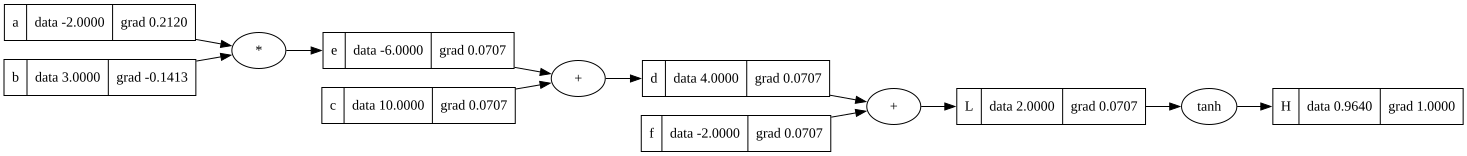

In [14]:
a=Value(-2.0,label='a')
b=Value(3.0,label='b')
c=Value(10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f');f.label='f'
L=d+f;L.label='L'
H=L.tanh();H.label='H'
H.backward()   
draw_dot(H)

In [15]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._prev=set(_children)
        self._backward=lambda:None
        self._op=_op
        self.label=label

    def __repr__(self):
        return f'Value(data={self.data}, grad={self.grad})'

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad+=out.grad
            other.grad+=out.grad
        out._backward=_backward
        return out
    def __radd__(self,other):
        return self+other
    def __sub__(self,other):
        return self+(other*(-1))
    def __rsub__(self,other):
        return self+other
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out

    def __rmul__(self,other):
        return self*other

    def __pow__(self,other):
        assert isinstance(other,(int,float)),'only int/float'
        out=Value(math.pow(self.data,other),(self,),f'**{other}')
        def _backward():
            self.grad+=other*(self.data**(other-1))*out.grad
        out._backward=_backward
        return out

    def __truediv__(self,other):
        return self*(other**(-1))

    def exp(self):
        out=Value(math.exp(self.data),(self,),'exp')
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out

    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0

        for node in reversed(topo):
            node._backward()
    def tanh(self):
        t=(self*2).exp()
        out=(t-1)/(t+1)
        return out
    


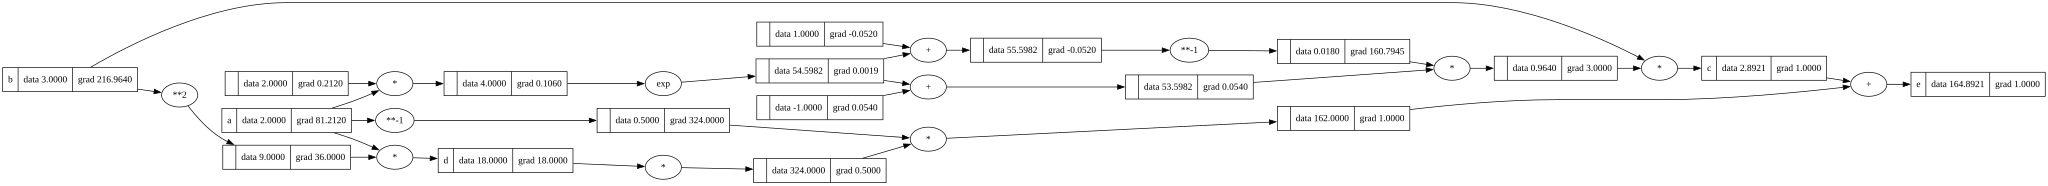

In [16]:
a=Value(2.0,label='a')
b=Value(3.0,label='b')
c=a.tanh()*b;c.label='c'
d=a*b**2;d.label='d'
e=d*d/a+c;e.label='e'
e.backward()
draw_dot(e)

In [17]:
import torch
import random

In [18]:
x1=torch.tensor([2.0],dtype=torch.float64,requires_grad=True)
x2=torch.tensor([0.0],dtype=torch.float64,requires_grad=True)
w1=torch.tensor([-3.0],dtype=torch.float64,requires_grad=True)
w2=torch.tensor([1.0],dtype=torch.float64,requires_grad=True)
b=torch.tensor([6.8813735870195432],dtype=torch.float64,requires_grad=True)
n=x1*w1+x2*w2+b
o=torch.tanh(n)


print(o.item())
o.backward()
print('---')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071067811865476
---
x2 0.4999999999999999
w2 0.0
x1 -1.4999999999999996
w1 0.9999999999999998


In [66]:
class Neuron:
    def __init__(self,nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    def __call__(self,x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    def parameters(self):
        return self.w+[self.b]
class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs=[neuron(x) for neuron in self.neurons]
        return outs
    def parameters(self):
        params=[p for neuron in self.neurons for p in neuron.parameters()]
        return params
class MLP:
    def __init__(self,nin,nouts):
        sizes=[nin]+nouts
        self.layers=[Layer(sizes[i],sizes[i+1]) for i in range(len(sizes)-1)]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    def parameters(self):
        out=[p for layer in self.layers for p in layer.parameters()]
        return out
study_rate=0.1
steps=10
model=MLP(3,[4,4,1])
xs=[[2.0,1.0,-3.0],
    [1.0,2.0,3.0],
    [-2.0,3.0,-1.0],
    [1.0,-1.2,1.0]]
ys=[1.0,-1.0,1.0,1.0]
for i in range(steps):
    ypred=[model(x)[0] for x in xs]
    loss=sum((y-yp)**2 for y,yp in zip(ys,ypred))
    for p in model.parameters():
        p.grad=0
    loss.backward()
    for p in model.parameters():
        p.data-=study_rate*p.grad
    print(i,loss.data)

0 2.723763234777893
1 1.4513060059162979
2 0.2142689454051092
3 0.14514921873370276
4 0.11056251695947848
5 0.08885774995633444
6 0.07402637167544393
7 0.06328453771768992
8 0.05516598614848742
9 0.04882653059146667


Value(data=0.7073097373918086, grad=0.0)


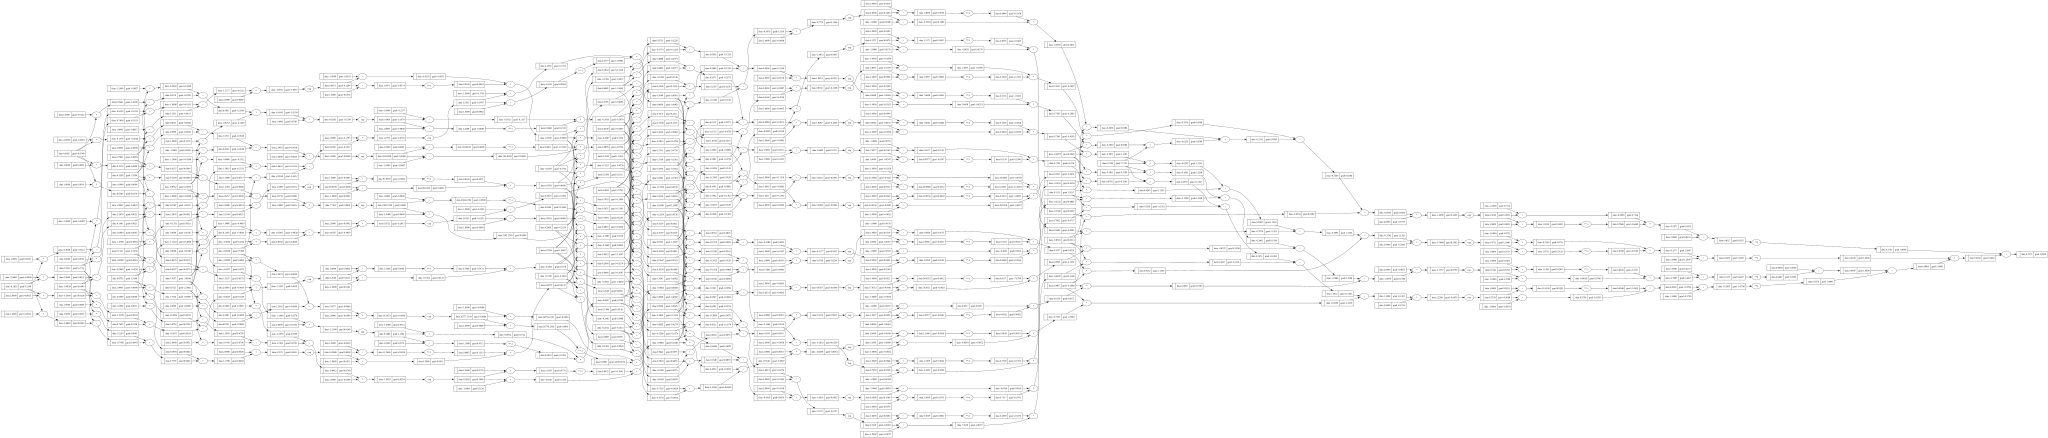

In [ ]:
xs=[[2.0,1.0,-3.0],
    [1.0,2.0,3.0],
    [-2.0,3.0,-1.0],
    [1.0,-1.2,1.0]]
ys=[1.0,-1.0,1.0,1.0]
ypred=[model(x)[0] for x in xs]
loss=sum(((y-yp)**2 for y,yp in zip(ys,ypred)))
print(loss)
loss.backward()
draw_dot(loss)